In [1687]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1688]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/WakacyjneWyzwanieML") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

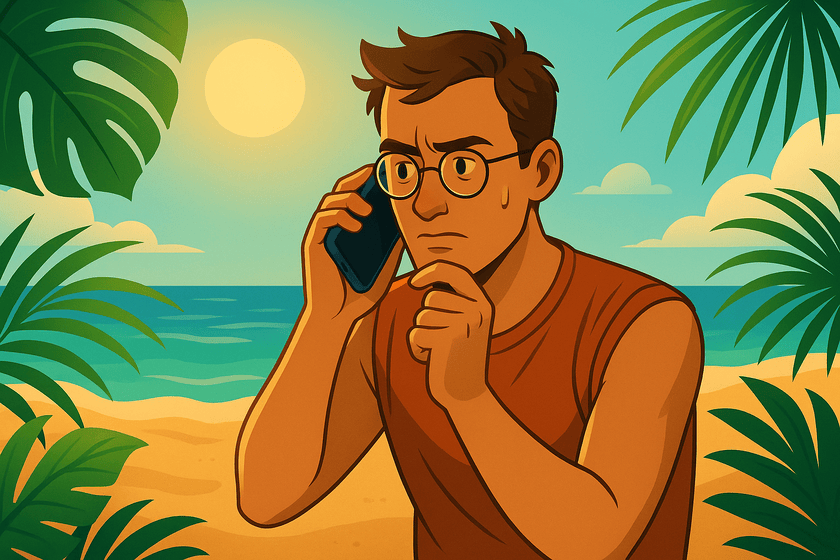

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


##Analiza danych i realcje

In [1689]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [1690]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [1691]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [1692]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [1693]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1694]:
titanic_df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [1695]:
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 1 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

In [1696]:
missing_cols = get_percentage_missing(titanic_df, axis=0)
missing_cols

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


In [1697]:
missing_rows_mi = get_percentage_missing(titanic_df, axis=1)
missing_rows_mi.unique()

array([ 9.09, 18.18, 27.27])

Najpierw sprawdzam ile danych brakuje, jakich danych brakuje i relacje między nimi.

In [1698]:
rows_3_missing_idx = missing_rows_mi[missing_rows_mi == 27.27].index
titanic_df.loc[rows_3_missing_idx]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,NaN,NaN,S
102,0,3,"Petroff, Mr. Pastcho (""Pentcho"")",male,NaN,0,0,349215,NaN,NaN,S
187,1,3,"O'Brien, Mrs. Thomas (Johanna ""Hannah"" Godfrey)",female,NaN,1,0,370365,NaN,NaN,Q
251,0,3,"Reed, Mr. James George",male,NaN,0,0,362316,NaN,NaN,S
271,0,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,NaN,NaN,S
432,1,3,"Thorneycroft, Mrs. Percival (Florence Kate White)",female,NaN,1,0,376564,NaN,NaN,S
445,1,3,"Johannesen-Bratthammer, Mr. Bernt",male,NaN,0,0,65306,NaN,NaN,S
496,0,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,NaN,NaN,C
594,0,3,"Bourke, Miss. Mary",female,NaN,0,2,364848,NaN,NaN,Q


In [1699]:
titanic_df.groupby('Pclass')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
2,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
3,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [1700]:
titanic_df.groupby('Sex')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
female,261.0,27.915709,14.110146,0.75,18.0,27.0,37.0,63.0
male,453.0,30.726645,14.678201,0.42,21.0,29.0,39.0,80.0


In [1701]:
titanic_df.groupby(['Pclass','Sex'])['Age'].describe()

count       mean        std   min     25%   50%    75%   max
Pclass Sex                                                                 
1      female   85.0  34.611765  13.612052  2.00  23.000  35.0  44.00  63.0
       male    101.0  41.281386  15.139570  0.92  30.000  40.0  51.00  80.0
2      female   74.0  28.722973  12.872702  2.00  22.250  28.0  36.00  57.0
       male     99.0  30.740707  14.793894  0.67  23.000  30.0  36.75  70.0
3      female  102.0  21.750000  12.729964  0.75  14.125  21.5  29.75  63.0
       male    253.0  26.507589  12.159514  0.42  20.000  25.0  33.00  74.0

In [1702]:
titanic_df['Embarked'].value_counts(dropna=False)

,count
Embarked,
S,644
C,168
Q,77
NaN,2


In [1703]:
titanic_df['Cabin'].str[0].value_counts(dropna=False)

,count
Cabin,
NaN,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [1704]:
titanic_df.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,194.0,86.771177,81.123003,0.0,31.3302,60.2875,103.19375,512.3292
2,169.0,20.489127,13.171854,0.0,13.0000,14.0000,26.00000,73.5000
3,430.0,13.886074,12.142212,0.0,7.7500,8.0500,15.53750,69.5500


##Uzupełnianie danych

Wypełnię braki w wieku za pomocą mediany na podstawie klasy i płci.

W embarked dam mode, ponieważ brakuje tylko dwóch danych.

W kabinach zostawię pierwszą literkę oznaczającą poziom/sektor, a przy nan wypełnie jako brak.

Przy flare uzupełnię jako mediana na podstawie danej klasy.

In [1705]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

In [1706]:
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

In [1707]:
titanic_df['Age'] = titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [1708]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0].fillna('Unknown') # Poprawione z none
titanic_df = titanic_df.drop(columns=['Cabin'])

In [1709]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


##Dodawanie kolumn

Dane zostały oczyszczone, pozostało tylko dodać kolumny i zakodować odpowiednio.

Dodam kolumny czy posażer podróżował samotnie czy nie oraz jak wielka jest rodzina.


In [1710]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1 # +1 z tym samym pasażerem

In [1711]:
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int) # czy jest sam czy nie

Usuwam kolumny name i ticket. Nie będą już potrzebne do przedstawiania danych, model by i tak nic nie zrobił z samym tesktem.


In [1712]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])

In [1713]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FamilySize,IsAlone
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,Unknown,2,0
2,1,1,female,38.0,1,0,71.2833,C,C,2,0
3,1,3,female,26.0,0,0,7.9250,S,Unknown,1,1
4,1,1,female,35.0,1,0,53.1000,S,C,2,0
5,0,3,male,35.0,0,0,8.0500,S,Unknown,1,1


##Pare wykresów przed zakodowaniem bo tak łatwiej. I drobne zmiany z Deck

/tmp/ipykernel_429/1236351448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='Deck', y='Survived', legend=False, palette='viridis', errorbar=None)


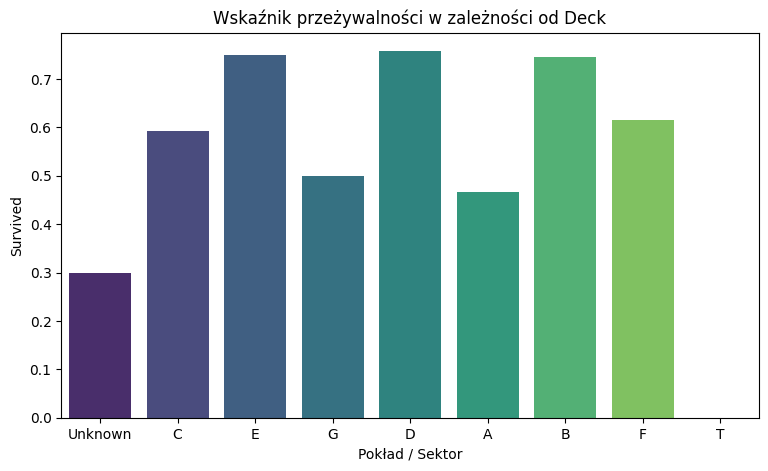

In [1714]:
plt.figure(figsize=(9, 5))

# Wykres przeżywalności według pokładu
sns.barplot(data=titanic_df, x='Deck', y='Survived', legend=False, palette='viridis', errorbar=None)

plt.title('Wskaźnik przeżywalności w zależności od Deck')
plt.xlabel('Deck')
plt.ylabel('Survived')

plt.show()

In [1715]:
def plot_categorical_column(df, column_name):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

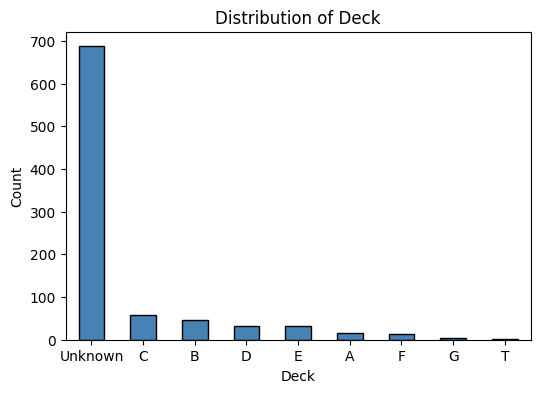

In [1716]:
plot_categorical_column(titanic_df, 'Deck')

In [1717]:
titanic_df['Deck'].value_counts()

,count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


Z powodu, że sektory A,F,G,T występują jako małe zbiory dodam je wszytskie razem jako rare_decks, żeby nie wpływało to źle na uczenie, bo jak widać na wykresie T ma zerową przeżywalność, a jest tylko jeden przypadek.

In [1718]:
rare_decks = ['A', 'F', 'G', 'T']
titanic_df['Deck'] = titanic_df['Deck'].replace(rare_decks, 'Rare')

In [1719]:
titanic_df['Deck'].value_counts()

,count
Deck,
Unknown,687
C,59
B,47
Rare,33
D,33
E,32


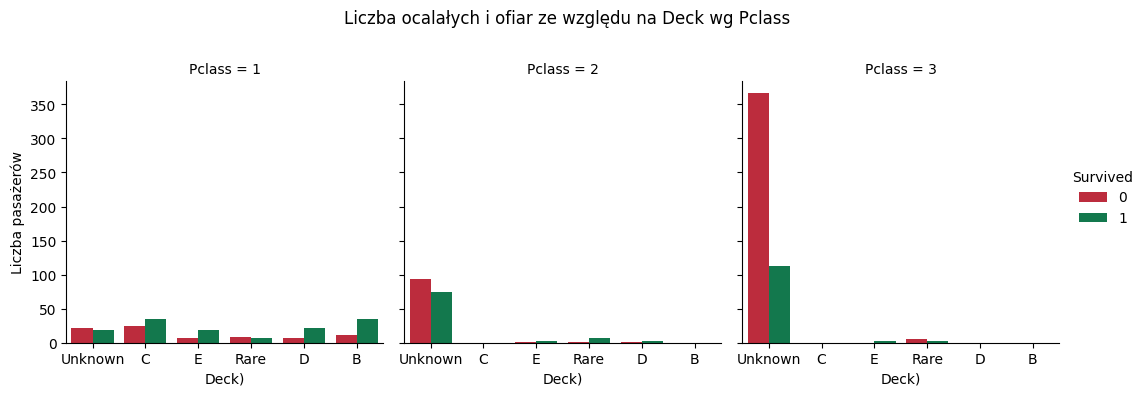

In [1720]:
g = sns.catplot(data=titanic_df, x='Deck', hue='Survived', col='Pclass', kind='count', palette=['#d4142a', '#028950'], height=4, aspect=0.9
)

g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Liczba ocalałych i ofiar ze względu na Deck wg Pclass')
g.set_axis_labels('Deck)', 'Liczba pasażerów')
g._legend.set_title('Survived')

plt.show()

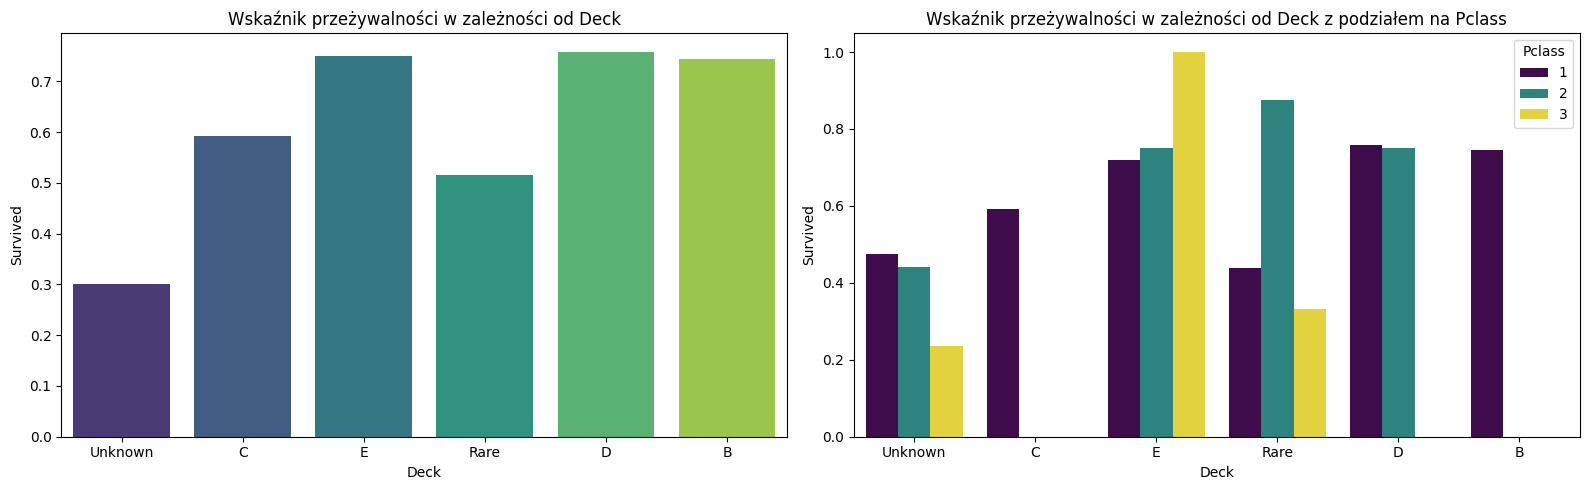

In [1721]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Wykres przeżywalności według pokładu
sns.barplot(data=titanic_df, x='Deck', y='Survived', hue='Deck', legend=False, palette='viridis', errorbar=None, ax=axes[0])

axes[0].set_title('Wskaźnik przeżywalności w zależności od Deck')
axes[0].set_xlabel('Deck')
axes[0].set_ylabel('Survived')


# Wykres przeżywalności według pokładu
sns.barplot(data=titanic_df, x='Deck', y='Survived', hue='Pclass', palette='viridis', errorbar=None, ax=axes[1])

axes[1].set_title('Wskaźnik przeżywalności w zależności od Deck z podziałem na Pclass')
axes[1].set_xlabel('Deck')
axes[1].set_ylabel('Survived')
axes[1].legend(title='Pclass')

plt.tight_layout()
plt.show()




Jak widać posiadając przypisany sektor zwiększał szanse na przeżycie, z wyjątkiem Rare w pierwszej klasie.

Jest widoczna różnica między 1 klasa, a 1 klasa z przepisanym sektorem. W klasie 2 i 3 można wyciągnąć podobne wnioski ale jak widać na wykresie ilościowym, są to nieporównywalnie mniejsze grupy w porównaniu z unknown.

##Kodowanie danych kategorialnych

Teraz przechodzimy do kodowania. W embarked i deck zastosuje one hot encoding, są to dane kategorialne, tak sama jak sex. Reszta danych jest okej jako liczby, isAlone jest jako 01.


In [1722]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1}) #binary encoding

In [1723]:
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked', 'Deck'], drop_first=False, dtype=int)

In [1724]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Deck_B,Deck_C,Deck_D,Deck_E,Deck_Rare,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,0,1,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,1,0,0,0,1,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,1,0,0,1,0,0,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,2,0,0,0,1,0,1,0,0,0,0
5,0,3,0,35.0,0,0,8.0500,1,1,0,0,1,0,0,0,0,0,1


##Wizualizacja danych

In [1725]:
def plot_numeric_histogram(df, column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [1726]:
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

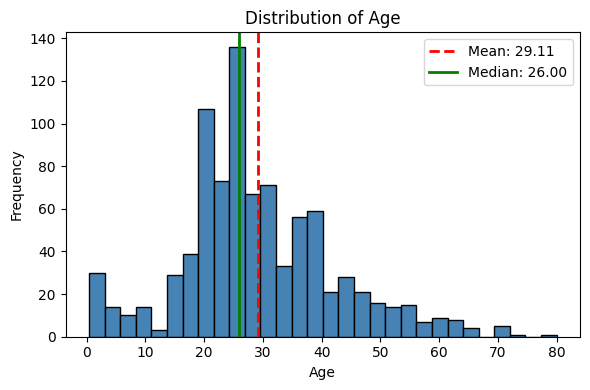

In [1727]:
plot_numeric_histogram(titanic_df, 'Age')

Widać rozkład zbliżony do normalnego, ale z wieloma outlierami.

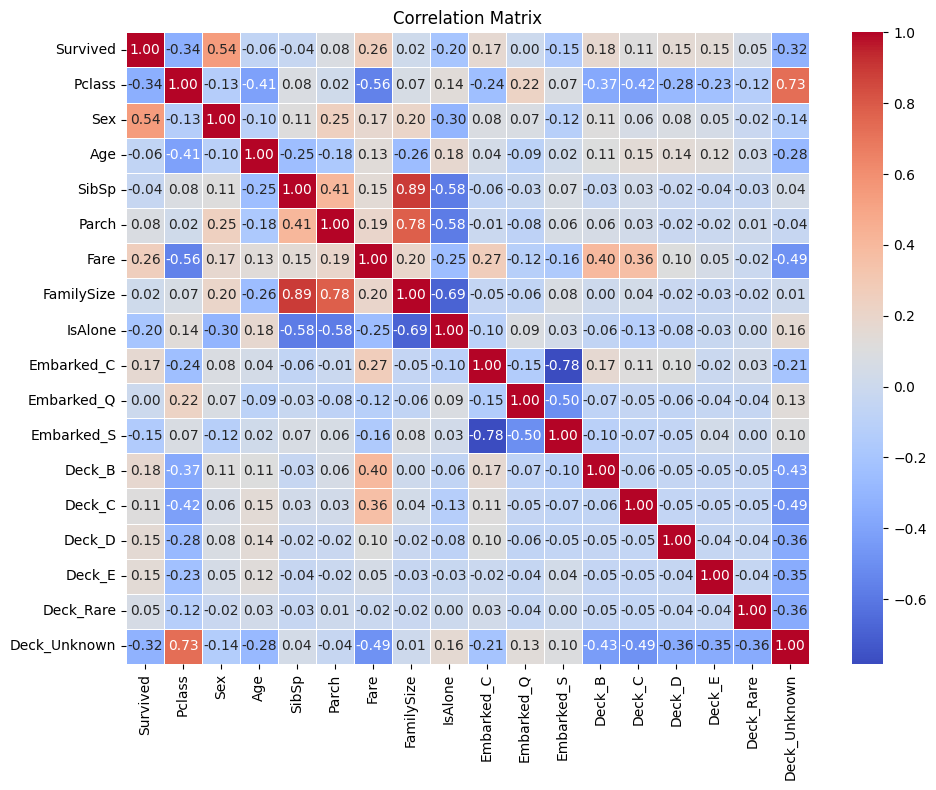

In [1728]:
plot_correlation_matrix(titanic_df)

Widać na heatmapie silne relacje między:

*   Przeżywalności, a płcią - większy procent kobiet przeżył
*   Opłatą a klasą - im wyższa klasa tym drożej
*   Deck B i C, a opłata - te sektory były najdroższe
*   Deck_Unknown, a opłata - najtańszy sektor
*   Sex, a isAlone - mężczyzn samontych było więcej
*   Embarked_C, a fare - najbogatsi wsiadli w Cherbourg



/tmp/ipykernel_429/908857897.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Mężczyźni (0)', 'Kobiety (1)'])


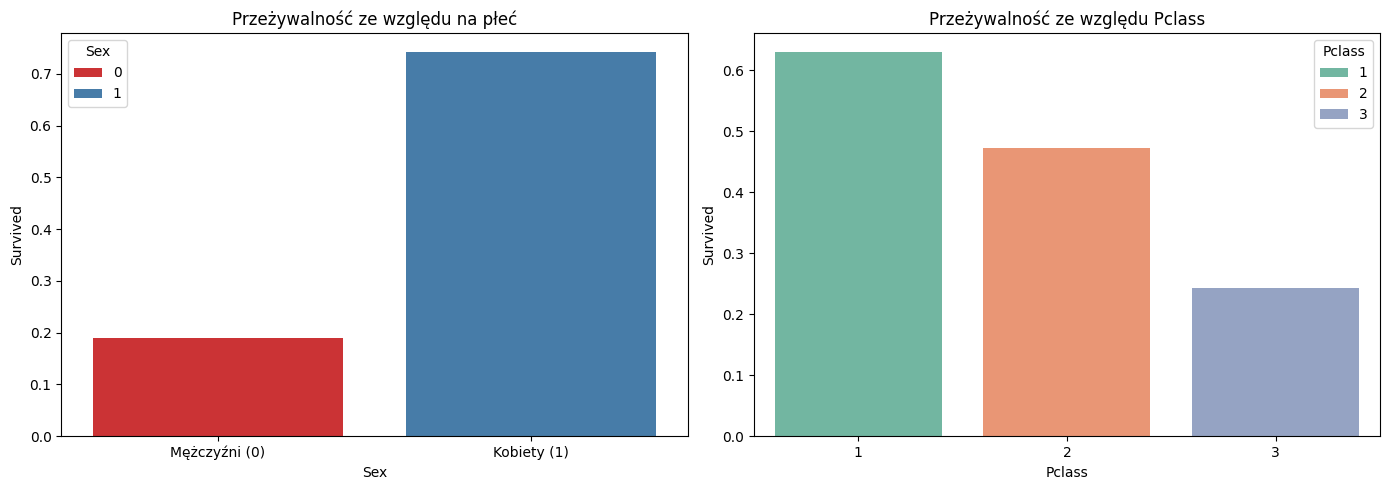

In [1729]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=titanic_df, x='Sex', y='Survived', hue='Sex', palette='Set1', ax=axes[0], errorbar=None)
axes[0].set_title('Przeżywalność ze względu na płeć')
axes[0].set_xticklabels(['Mężczyźni (0)', 'Kobiety (1)'])
axes[0].set_ylabel('Survived')

sns.barplot(data=titanic_df, x='Pclass', y='Survived', hue='Pclass', palette='Set2', ax=axes[1], errorbar=None)
axes[1].set_title('Przeżywalność ze względu Pclass')
axes[1].set_ylabel('Survived')

plt.tight_layout()
plt.show()

Jak widać na wykresie survived od sex, kobiety miały o wiele większą szanse na przeżycie. Tak samo im wyższa klasa podróżującego tym większa szansa na przeżycie.

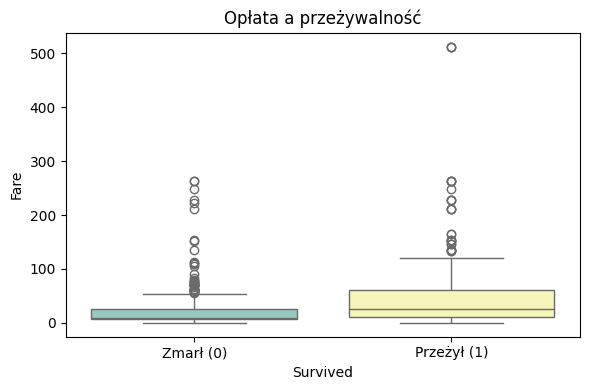

In [1730]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=titanic_df, x='Survived', y='Fare', palette='Set3', hue='Survived', legend=False)

plt.title('Opłata a przeżywalność')
plt.xticks([0, 1], ['Zmarł (0)', 'Przeżył (1)'])

plt.tight_layout()
plt.show()

Jak widać na wykresie przeżywalności a opłaty jest bardzo dużo outlierów. Większość opłat jest stosunkowo niewielka, natomiast jest trochę wartości odstających. W takim przpadku spróbuje to wyskalować logarytmicznie.

In [1731]:
titanic_df['Fare_log'] = np.log1p(titanic_df['Fare'])
titanic_df = titanic_df.drop(columns=['Fare'])

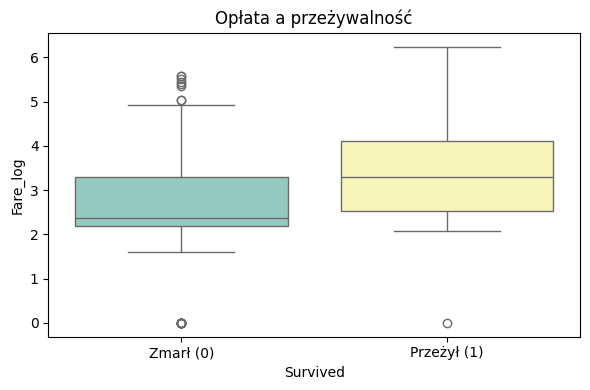

In [1732]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=titanic_df, x='Survived', y='Fare_log', palette='Set3', hue='Survived', legend=False)

plt.title('Opłata a przeżywalność')
plt.xticks([0, 1], ['Zmarł (0)', 'Przeżył (1)'])

plt.tight_layout()
plt.show()

Widać o wiele mniej outlierów. Fare zostało poprawnie wyskalowane.

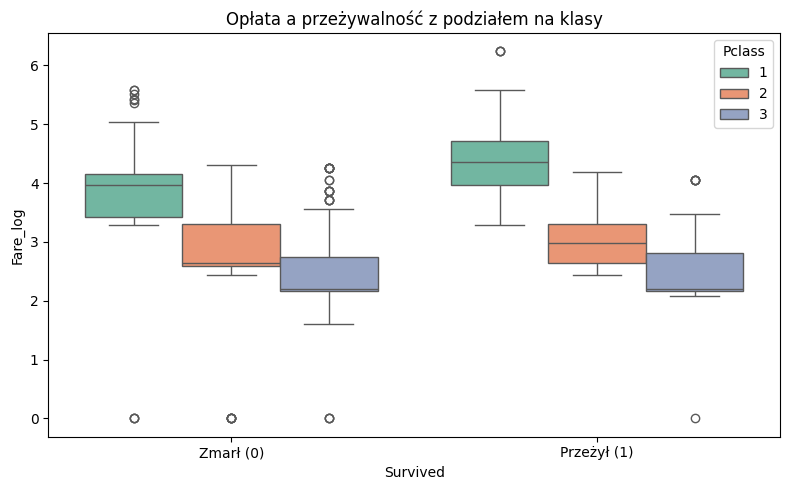

In [1733]:
# Wykres dodany z podziałem na klasy
plt.figure(figsize=(8, 5))

# Podział na klasy
sns.boxplot(data=titanic_df, x='Survived', y='Fare_log', hue='Pclass', palette='Set2')

plt.title('Opłata a przeżywalność z podziałem na klasy')
plt.xticks([0, 1], ['Zmarł (0)', 'Przeżył (1)'])
plt.xlabel('Survived')
plt.ylabel('Fare_log')
plt.legend(title='Pclass')

plt.tight_layout()
plt.show()

Im droższy bilet był w 1 klasie tym większe były szanse na przeżycie. Nie widać takiej realacji w 2 i 3 klasie.

/tmp/ipykernel_429/51283457.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Z rodziną (0)', 'Samotnie (1)'])


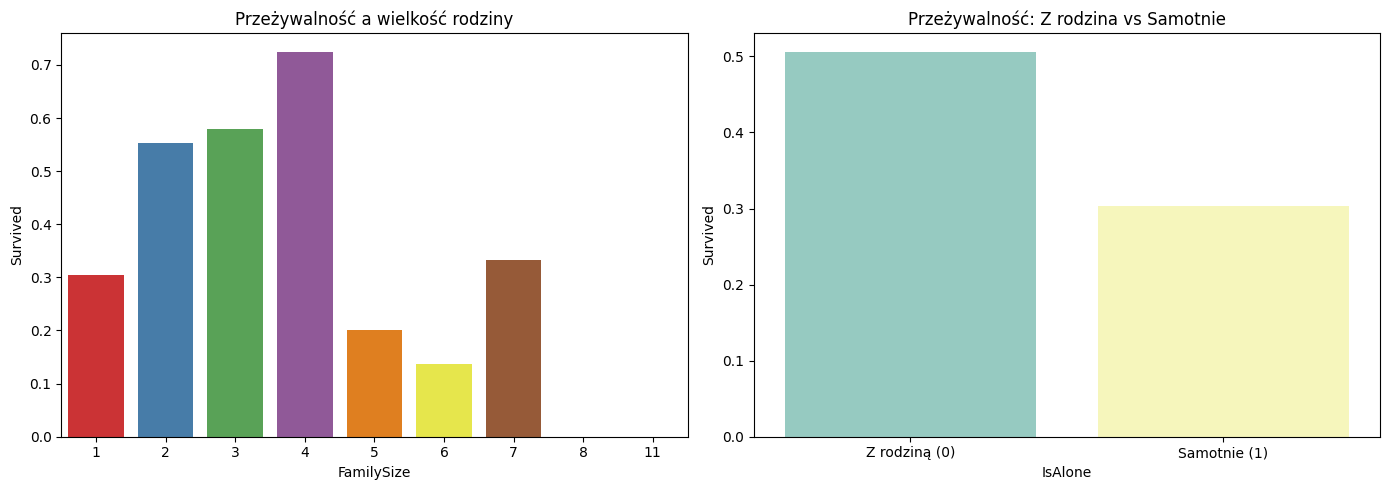

In [1734]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=titanic_df, x='FamilySize', y='Survived', hue='FamilySize', palette='Set1', ax=axes[0], errorbar=None, legend=False)
axes[0].set_title('Przeżywalność a wielkość rodziny')
axes[0].set_xlabel('FamilySize')

sns.barplot(data=titanic_df, x='IsAlone', y='Survived', hue='IsAlone', palette='Set3', ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Przeżywalność: Z rodzina vs Samotnie')
axes[1].set_xticklabels(['Z rodziną (0)', 'Samotnie (1)'])

plt.tight_layout()
plt.show()

Tak jak widać na wykresie, większe szanse na przeżycie miały osoby podróżujące w towarzystwie rodziny niż samotnie. Największe wspóczynnik na przyżycie miały rodziny liczące od 2 do 4 członków, wskaźnik ten znacząco spadał przy większych rodzinach

In [1735]:
def scatterplot(df, column_name, y):
    """
    Plots a scatterplot between the chosen column and 'charges'.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot against 'charges'.
    Returns:
        None. Displays the scatterplot.
    """
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=column_name, y=y, hue='Survived', palette=['#d4142a', '#028950'], alpha=0.6)
    plt.title(f'{column_name} vs {y}')
    plt.xlabel(column_name)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

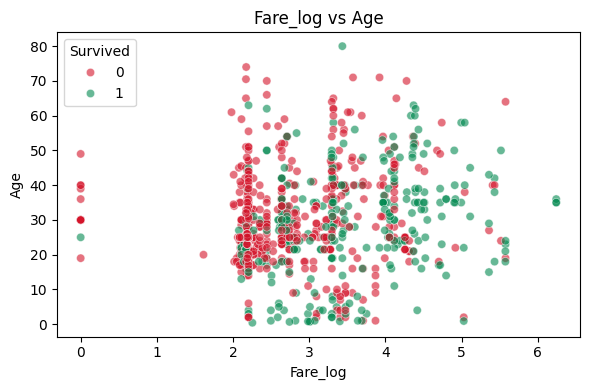

In [1736]:
scatterplot(titanic_df, 'Fare_log', 'Age')

Im droższy bilet się miało tym była większa szansa na przeżycie.

## Wnioski

Największe statystycznie szanse miała na przeżycie kobieta z klasy 1, posiadająca kabinę, będąca z rodziną w wielkości między 2, a 4 członków rodziny.

Nie jestem pewien czy jest sens podawania Deck do klasy 2 i 3, gdzie tych przypadków jest tak mało i mogą być niereprezentatywne, z porównaniem do Unknown.

Za to Deck ma jak najbardziej sens dla klasy 1, gdzie te dane są ładnie rozłożone pomiędzy różnymi sektorami, a Unknown.

Myślałem nad tym, żeby usunąć Deck dla klasy 2 i 3, a zostawić tylko dla klasy 1, ewentualnie całkiem usunąć Deck, ale już zostawię tak jak jest.